In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

plt.style.use("plot_style.mplstyle")
plt.rc('text', usetex=True)

In [ ]:
adden = "m2_rp25" 

with open(f"Fallback_Data/rel_p_e_{adden}_a0p2.txt", "r") as f:
    rel_p_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"Fallback_Data/rel_p_t_{adden}_a0p2.txt", "r") as f:
    rel_p_T = {k: np.array(v) for k, v in json.load(f).items()}

with open(f"Fallback_Data/rel_r_e_{adden}_a0p2.txt", "r") as f:
    rel_r_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"Fallback_Data/rel_r_t_{adden}_a0p2.txt", "r") as f:
    rel_r_T = {k: np.array(v) for k, v in json.load(f).items()}

with open(f"Fallback_Data/rel_sch_e_{adden}.txt", "r") as f:
    rel_sch_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"Fallback_Data/rel_sch_t_{adden}.txt", "r") as f:
    rel_sch_T = {k: np.array(v) for k, v in json.load(f).items()}

adden = "m2_rp21"

with open(f"Fallback_Data/n_e_{adden}.txt", "r") as f:
    n_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"Fallback_Data/n_t_{adden}.txt", "r") as f:
    n_T = {k: np.array(v) for k, v in json.load(f).items()}

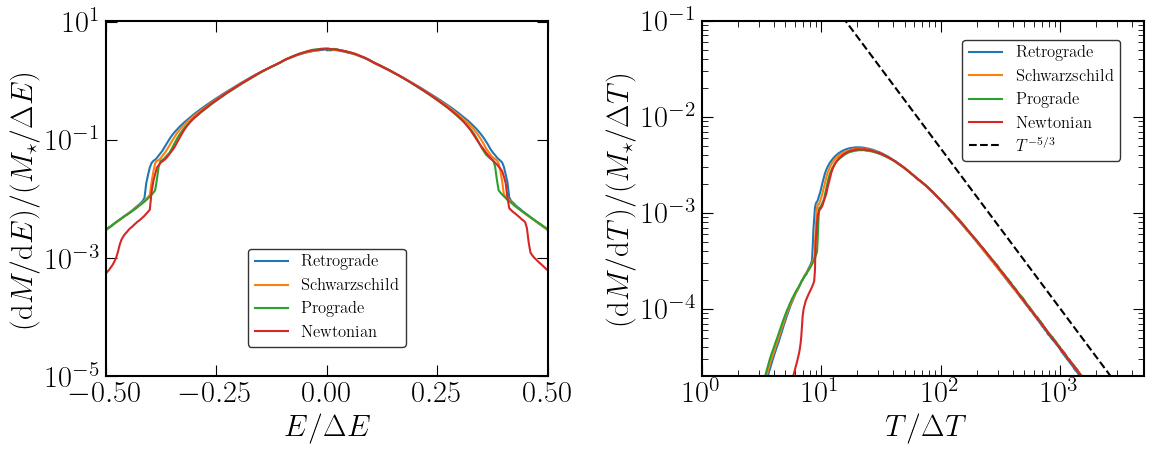

In [3]:
# Build dicts

# Plot
fig, (axE, axT) = plt.subplots(1, 2, figsize=(12, 5))

# Energy
bins_E = np.linspace(-2, 2, 200)
axE.plot(rel_r_E["x"], rel_r_E["y"], label="Retrograde")
axE.plot(rel_sch_E["x"], rel_sch_E["y"], label="Schwarzschild")
axE.plot(rel_p_E["x"], rel_p_E["y"], label="Prograde")
axE.plot(n_E["x"],   n_E["y"],   label="Newtonian")

axE.set_yscale('log')
axE.set_xlabel(r'$E / \Delta E$')
axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')
axE.set_xlim(-0.5,0.5)
axE.set_ylim(1e-5)

axE.legend(
    loc='center',            # the point on the legend box to anchor
    bbox_to_anchor=(0.5, 0.22),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

# Period
axT.plot(rel_r_T["x"], rel_r_T["y"], label="Retrograde")
axT.plot(rel_sch_T["x"], rel_sch_T["y"], label="Schwarzschild")
axT.plot(rel_p_T["x"], rel_p_T["y"], label="Prograde")
axT.plot(n_T["x"],   n_T["y"],   label="Newtonian")

bins_T = np.logspace(0, 6, 200)
axT.plot(bins_T, 10 * bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
axT.set_xscale('log')
axT.set_yscale('log')
axT.set_xlabel(r'$T / \Delta T$')
axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')
axT.set_xlim(1,5000)
axT.set_ylim(2e-5,0.1)
axT.legend(
    loc='upper left',            # the point on the legend box to anchor
    bbox_to_anchor=(0.57, 0.97),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

plt.tight_layout()
plt.show()